# 📈 Forecasting de revenue - Hapy Cow Ice Cream


## Créditos

Este notebook está basado en el caso de estudio:

> **Caso N.° HK1207-PDF-ENG**  
> University of Hong Kong / Harvard Business Publishing Education  
> Disponible en: https://hbsp.harvard.edu/product/HK1207-PDF-ENG

El material del caso es propiedad de la University of Hong Kong y distribuido por Harvard Business Publishing. Su uso en este curso es exclusivamente con fines académicos.

---


## Contexto e introducción

En el caso de Happy Cow Ice Cream, se busca desarrollar un modelo de forecasting a partir de datos diarios de ventas por producto, con el fin de apoyar decisiones de negocio 📊. Debido al alto nivel de ruido y variabilidad en la información diaria, el análisis se enfocará en construir un forecast semanal, permitiendo identificar patrones más estables como tendencias y posibles estacionalidades 📅. No obstante, el problema presenta retos importantes, como la limitada cantidad de datos disponibles y la influencia de factores externos en la demanda, lo que hace necesario complementar el modelado con un análisis exploratorio cuidadoso 🧠.

## 🧩 Enunciado

Como consultor externo, se le solicita desarrollar un **modelo predictivo de revenue** para los productos más relevantes, generando pronósticos **semanales (cuatro semanas adelante)**. Los datos se encuentran en el archivo `ice_cream_data_daily.csv`, que incluye:

- **Product**
- **Date_clean**
- **Revenue**

El objetivo es producir pronósticos confiables que apoyen la planificación, reduzcan el desperdicio y mejoren la eficiencia operativa. 📊🤝


In [77]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

data = pd.read_csv("ice_cream_data_daily.csv", delimiter=',', encoding="utf8")

# ✅ Criterios de evaluación – Descripción

1) **Exploración y limpieza de los datos**  
Realiza una exploración clara de la serie y sus variables (tendencias, estacionalidad, valores atípicos, faltantes). Limpia y estandariza formatos (fechas, unidades, precios) y deja trazabilidad de las decisiones tomadas para garantizar un conjunto de datos listo para modelar.

2) **Modelo “base”, métrica y separación temporal**  
Implementa un modelo base razonable para tu problema (p. ej., media móvil) y evalúalo con una métrica coherente con el negocio (MAE, RMSE o MAPE). Separa correctamente entrenamiento y test respetando la temporalidad, evitando cualquier fuga de información.

3) **Modelo avanzado para mejorar predicciones**  
Construye un modelo más sofisticado (ARIMA/SARIMA/SARIMAX, Prophet, ETS o un enfoque de ML con rasgos temporales/exógenas) y justifica su elección. Demuestra mejora frente al modelo base usando la misma ventana de evaluación y la misma métrica.

4) **Uso del modelo: predicción 4 semanas adelante**  
Selecciona un modelo ganador y genera un pronóstico operativo a **4 semanas** (multi‐paso). Entrega las predicciones en una tabla y un gráfico del horizonte, idealmente con intervalos de confianza y una breve guía de cómo reproducir el proceso.


>## Preguntas pendientes
>* Deberíamos tener en cuenta la estructura de precios diferenciados?
>* Por qué doble scoop o triple scoop aparecen negativos?
>* Cómo tratar los outliers? Deberíamos detectar si los ourliers se deben a las promociones? En caso de que se debería hacer? Eliminarlos?


# Punto 1

## Analisis Inicial

In [78]:
data.info()
data.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 19032 entries, 0 to 19031
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Product     19032 non-null  str    
 1   Date_clean  19032 non-null  str    
 2   Revenue     19032 non-null  float64
dtypes: float64(1), str(2)
memory usage: 446.2 KB


,Product,Date_clean,Revenue
count,19032,19032,19032.000000
unique,104,183,NaN
top,1 Topping,2017-04-01,NaN
freq,183,104,NaN
mean,NaN,NaN,14.390343
std,NaN,NaN,46.504922
min,NaN,NaN,-884.000000
25%,NaN,NaN,0.000000
50%,NaN,NaN,0.000000
75%,NaN,NaN,0.000000


In [79]:
data.duplicated().sum()

np.int64(0)

>* Hay mucha variación el el revenue. El revenue tiene una media de 14.39 dolares? con una desviación estandar de 46.50. Si asumimos normalidad (se puede?), en la mayoría de los casos, cada producto diaramente genera un revenue entre los 0 y los 60 dolares. Hay que tener en cuenta los valores negativos
>* Hay valores negativos (Revisado)
>* Hay 104 productos únicos, son demasiados (Revisado)
>* El tipo de dato de la fecha es str no datetime (Revisado)
>* En un principio parece no haber valores nulos (Revisado)
>* Teniendo en cuenta la media y la desviación estandar vale la pena revisar el valor mínimo (-884), máximo (806) y más outliers 

## Revisiones

### Valores negativos

In [80]:
# Mostrar productos ordenados por revenue de forma ascendente
data.groupby('Product')['Revenue'].sum().sort_values(ascending=False)

Product
S. Caramel St                       25201.79338
Mint Choco  St                      14861.04761
Mango St                            14128.30953
Chocolate St                        13906.33333
Pure Coco . St                      13570.33333
Strawberry St                       11541.50000
S. Caramel Staff                    10226.21211
Chai Tea st                          9952.83333
Hazelnut St                          9824.66666
Green Tea St                         9667.50000
Banana Caramel St                    9197.49999
Waffle Cone St                       8707.51613
Mango Staff                          8030.09090
Chocolate Staff                      6863.87878
Pure Coconut Staff                   5729.09090
Mint Choco Staff                     5542.87878
Strawberry Staff                     5426.75757
Pina Colada St                       5301.50000
IceCream Sand St                     5010.00000
Coffee  St                           4938.33333
Vanilla Bean St                 

In [81]:
descuentos = [
    "ZALORA Ecoupon Buy 1 Get 1 Scoop",
    "Stamp Card REDEEM ST",
    "Gift coupon 3 cone",
    "Triple Scoop",
    "Staff Off -$2",
    "Triple Scoop Staff",
    "Gift Voucher ST",
    "Registration day $20",
    "Finger B 100",
    "Building Promotion",
    "Asia Research Free Scoop",
    "Free Scoop Grassroot",
    "Triple Scoop ST",
    "Double Scoop",
    "Double Scoop Staff",
    "Double Scoop ST",
]

data = data[~data["Product"].isin(descuentos)].copy()

data.groupby('Product')['Revenue'].sum().sort_values(ascending=True)

Product
Gift Voucher Reg                 0.00000
Lush Shampoo Bar $60             0.00000
LUSH FOOT POWDER                 0.00000
Tub Staff                        0.00000
Tax                              0.00000
Single Scoop Staff               0.00000
Single Scoop ST                  0.00000
Single Scoop                     0.00000
ZALORA $30 Spent Coupon          0.00000
Tub Ice Cream                    0.00000
Tub Ice Cream ST                 0.00000
3 Topping                       20.00000
Purchase  Gift Voucher st       26.00000
3 Topping Staff                 56.00000
1 Topping                       79.90566
Apricot                         80.00000
Cus IC Sand Staff               84.00000
Granola                        100.00000
1 Topping Staff                131.00000
Cus. IC Sand St                180.00000
Up 3 Toppings  ST              196.00000
Miscellenous                   293.00000
Ginger                         320.00000
1 Toppings St                  333.00000
Red Bean

>* Esto es un reflejo directo de las perdidas generadas a partir de los decuentos, promociones y diversas estrategias para atraer clientes como Building Promotion, Registration Day $20, Staff Off -$2, Stamp Card Redeem ST
>* Hace falta información para saber por qué Double Scoop y Tripe Scoop aparecen negativos

### Cantidad de productos únicos

In [82]:
data['Product'].value_counts()

Product
1 Topping                    183
1 Topping Staff              183
1 Toppings St                183
3 Topping                    183
3 Topping Staff              183
Apricot                      183
Apricot ST                   183
Apricot Staff                183
Banana Caramel  /            183
Banana Caramel St            183
Banana Staff                 183
Chai Tea                     183
Chai Tea Staff               183
Chai Tea st                  183
Cherry Alm Staff             183
Cherry Almond                183
Cherry Almond Fudge st       183
Chocoate Cookies             183
Chocolate                    183
Chocolate St                 183
Chocolate Staff              183
Coffee                       183
Coffee  St                   183
Coffee Staff                 183
Cus IC Sand Staff            183
Cus. IC Sand St              183
Gift Voucher Reg             183
Ginger                       183
Ginger St                    183
Ginger Staff                 183
Gr

>* producto_x, producto_x st y producto_x staff, son productos diferentes? Investigando el documento se plantea que este se debe a que la universidad de Hong Kong tiene una estructura de precios diferenciada cobrando diferente a los visitantes studiantes y staff (st -> precio estudiantes, staff -> precio staff). por ahora se plantea agrupar los valores por producto 
>* se observa que para todos los productos hay 183 registros, es decir el registro diaro del revenue por producto a través de más o menos 6 meses

In [83]:
# Elimina "Staff" y "St" (sin importar mayúsculas) al final de los nombres
data['Product_clean'] = data['Product'].str.replace(r'\s+(Staff|ST|st|St)$', '', regex=True).str.strip()

# Elimina cualquier barra ("/") al final de los nombres, junto con espacios adicionales.
data['Product_clean'] = data['Product_clean'].str.replace(r'\s+(/)$', '', regex=True).str.strip()

# Agrupa por día y producto, sumando la columna de ingresos
revenue_por_dia = data.groupby(['Date_clean', 'Product_clean'])['Revenue'].sum().reset_index()

revenue_por_dia['Date_clean'] = pd.to_datetime(revenue_por_dia['Date_clean'], errors='coerce')

revenue_por_dia['Product_clean'].value_counts()


revenue_por_dia.info()
revenue_por_dia.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 8601 entries, 0 to 8600
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date_clean     8601 non-null   datetime64[us]
 1   Product_clean  8601 non-null   str           
 2   Revenue        8601 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 201.7 KB


,Date_clean,Product_clean,Revenue
count,8601,8601,8601.000000
unique,NaN,47,NaN
top,NaN,1 Topping,NaN
freq,NaN,183,NaN
mean,2017-07-01 00:00:00,NaN,34.402511
min,2017-04-01 00:00:00,NaN,0.000000
25%,2017-05-16 00:00:00,NaN,0.000000
50%,2017-07-01 00:00:00,NaN,0.000000
75%,2017-08-16 00:00:00,NaN,30.000000
max,2017-09-30 00:00:00,NaN,846.000000


>* El número de diferentes productos disminuyó de 104 a 59
>* El número de registros paso de 19032 a 10797

In [84]:
# Actualizar la variable 'data' con el nuevo DataFrame 'revenue_por_dia'
data_original = data.copy()
data = revenue_por_dia.copy()

In [85]:
data['Product_clean'].value_counts()

Product_clean
1 Topping                  183
1 Toppings                 183
3 Topping                  183
Apricot                    183
Banana                     183
Banana Caramel             183
Chai Tea                   183
Cherry Alm                 183
Cherry Almond              183
Cherry Almond Fudge        183
Chocoate Cookies           183
Chocolate                  183
Coffee                     183
Cus IC Sand                183
Cus. IC Sand               183
Gift Voucher Reg           183
Ginger                     183
Granola                    183
Green Tea                  183
Hazelnut                   183
Hezelnut                   183
Ice Cream SAND             183
Ice Cream Sand             183
IceCream Sand              183
LUSH FOOT POWDER           183
Lime Coconut               183
Lush Shampoo Bar $60       183
Mango                      183
Mint Choco                 183
Miscellenous               183
Pina Colada                183
Pistachio                

### Tratamiento de valores nulos o faltantes

In [86]:
# 1. Preparación previa (Asegúrate de tener Date_clean como datetime)
data['Date_clean'] = pd.to_datetime(data['Date_clean'])

# 2. Definir el rango ideal global (del primer al último día de toda la base)
rango_global = pd.date_range(start=data['Date_clean'].min(), end=data['Date_clean'].max(), freq='D')

# 3. Diccionario para guardar los resultados
reporte_faltantes = {}

# 4. Agrupar por producto y comparar cada uno contra el rango global
for producto, grupo in data.groupby('Product_clean'):
    # Sacamos las fechas únicas que tiene este producto específico
    fechas_producto = grupo['Date_clean'].unique()
    
    # Encontramos la diferencia
    faltantes = rango_global.difference(fechas_producto)
    
    # Guardamos en el reporte
    reporte_faltantes[producto] = {
        'cantidad': len(faltantes),
        'fechas': faltantes
    }

# 5. Mostrar resultados de forma ordenada
for producto, info in reporte_faltantes.items():
    if info['cantidad'] > 0:
        print(f"Producto: {producto}")
        print(f" - Días faltantes: {info['cantidad']}")
        # Mostramos las primeras 5 fechas para no saturar la pantalla
        print(f" - Primeras fechas faltantes: {info['fechas'][:5].strftime('%Y-%m-%d').tolist()}")
        print("-" * 30)

>* Como en el análisis inicial no se vieron valores nulos a simple vista, se buscó por días faltantes desde el primero hasta el último día para cada producto y no se encontro ninguno

### Resample semanal

In [87]:
data.head()

,Date_clean,Product_clean,Revenue
0,2017-04-01,1 Topping,0.0
1,2017-04-01,1 Toppings,0.0
2,2017-04-01,3 Topping,0.0
3,2017-04-01,Apricot,0.0
4,2017-04-01,Banana,0.0


In [88]:
data_semanal = (
    data
    .groupby(["Product_clean", pd.Grouper(key="Date_clean", freq="W")])["Revenue"]
    .sum()
    .reset_index()
)
data_semanal.info()

data = data_semanal.copy()

<class 'pandas.DataFrame'>
RangeIndex: 1269 entries, 0 to 1268
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Product_clean  1269 non-null   str           
 1   Date_clean     1269 non-null   datetime64[us]
 2   Revenue        1269 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 29.9 KB


### Escoger los valores más relevantes

In [89]:
data.head(20)

,Product_clean,Date_clean,Revenue
0,1 Topping,2017-04-02,0.00000
1,1 Topping,2017-04-09,0.00000
2,1 Topping,2017-04-16,0.00000
3,1 Topping,2017-04-23,10.00000
4,1 Topping,2017-04-30,8.00000
5,1 Topping,2017-05-07,4.00000
6,1 Topping,2017-05-14,5.00000
7,1 Topping,2017-05-21,12.00000
8,1 Topping,2017-05-28,0.00000
9,1 Topping,2017-06-04,8.00000


In [90]:
product_col = "Product_clean"

pareto = (
    data
    .groupby(product_col)["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

pareto["Aporte (%)"]   = pareto["Revenue"] / pareto["Revenue"].sum() * 100
pareto["Acumulado (%)"] = pareto["Aporte (%)"].cumsum()
pareto["Revenue"]      = pareto["Revenue"].map("${:,.0f}".format)
pareto["Aporte (%)"]   = pareto["Aporte (%)"].map("{:.2f}%".format)
pareto["Acumulado (%)"] = pareto["Acumulado (%)"].map("{:.2f}%".format)

pareto.index = range(1, len(pareto) + 1)
pareto.index.name = "#"

#print(pareto.rename(columns={product_col: "Producto"}).to_string())
pareto.rename(columns={product_col: "Producto"})

,Producto,Revenue,Aporte (%),Acumulado (%)
#,,,,
1,S. Caramel,"$38,988",13.18%,13.18%
2,Mango,"$26,469",8.95%,22.12%
3,Chocolate,"$24,769",8.37%,30.49%
4,Mint Choco,"$22,964",7.76%,38.25%
5,Strawberry,"$20,728",7.01%,45.26%
6,Pure Coco .,"$16,810",5.68%,50.94%
7,Chai Tea,"$15,459",5.22%,56.16%
8,Waffle Cone,"$15,113",5.11%,61.27%
9,Green Tea,"$14,924",5.04%,66.32%


Observando los resultado obtenidos de esta tabla de pareto se logró observar que el 80% de las ganancias se encuentra en los primeros 13 productos, los cuales serán a los que se construiran los diferentes modelos.

In [101]:
# Extraer la lista de los productos que representan el 80% del revenue acumulado
productos_top_80 = pareto[pareto["Acumulado (%)"].str.rstrip('%').astype(float) <= 80][product_col].tolist()
print("Productos que representan el 80% del revenue acumulado:")
for producto in productos_top_80:
    print(f"- {producto}")

data = data[data[product_col].isin(productos_top_80)].copy()

Productos que representan el 80% del revenue acumulado:
- S. Caramel
- Mango
- Chocolate
- Mint Choco
- Strawberry
- Pure Coco .
- Chai Tea
- Waffle Cone
- Green Tea
- Hazelnut
- Banana Caramel
- Pina Colada


### Descomposición aditiva por producto


✅ Descomposición completada para 12 productos.


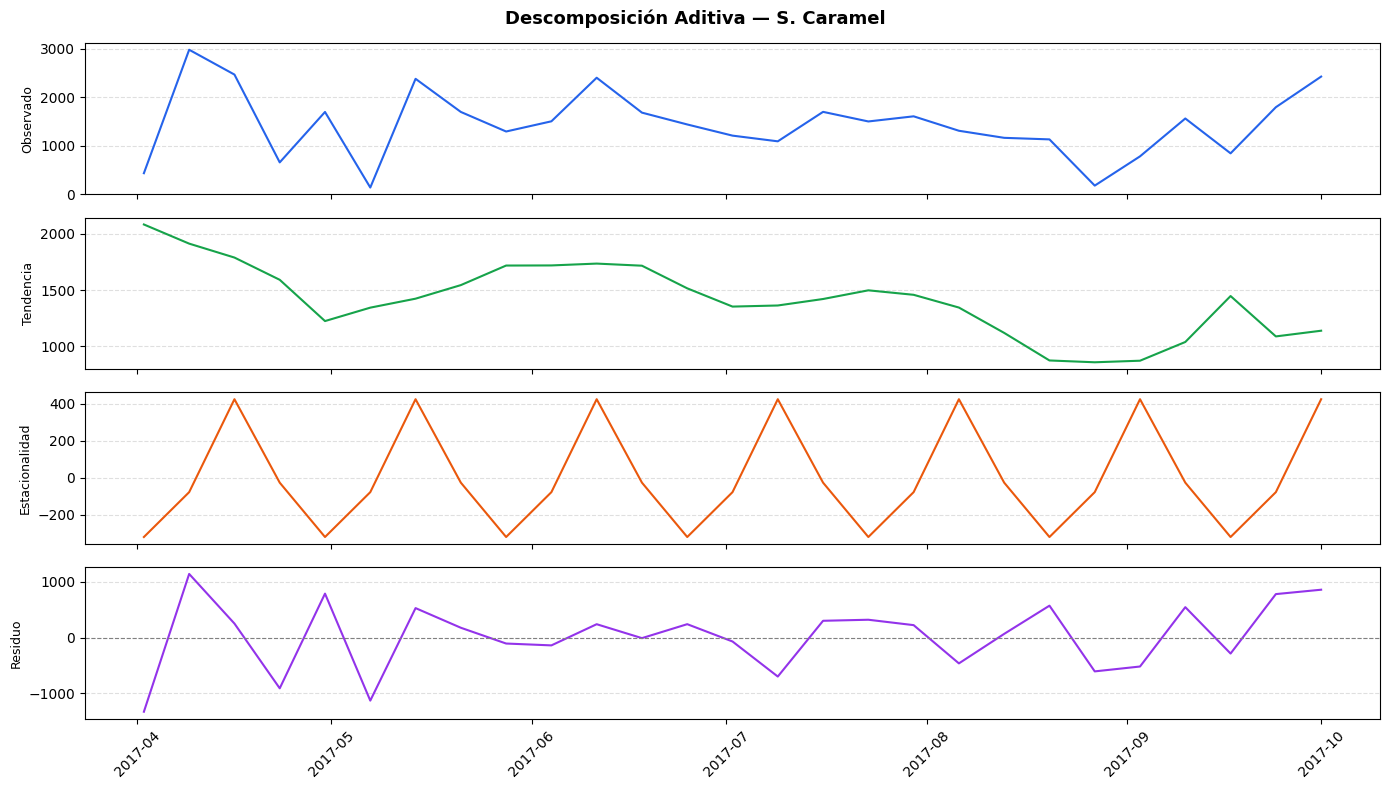

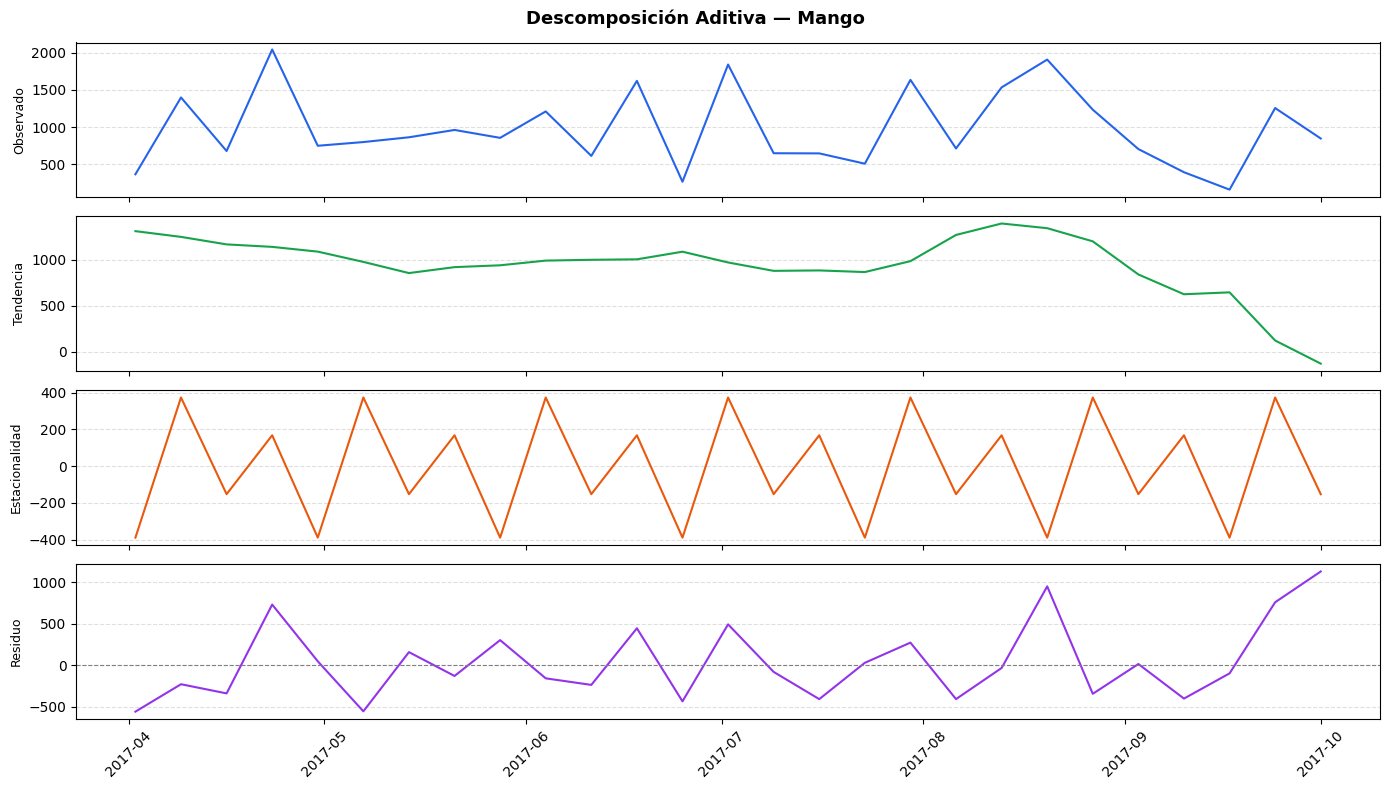

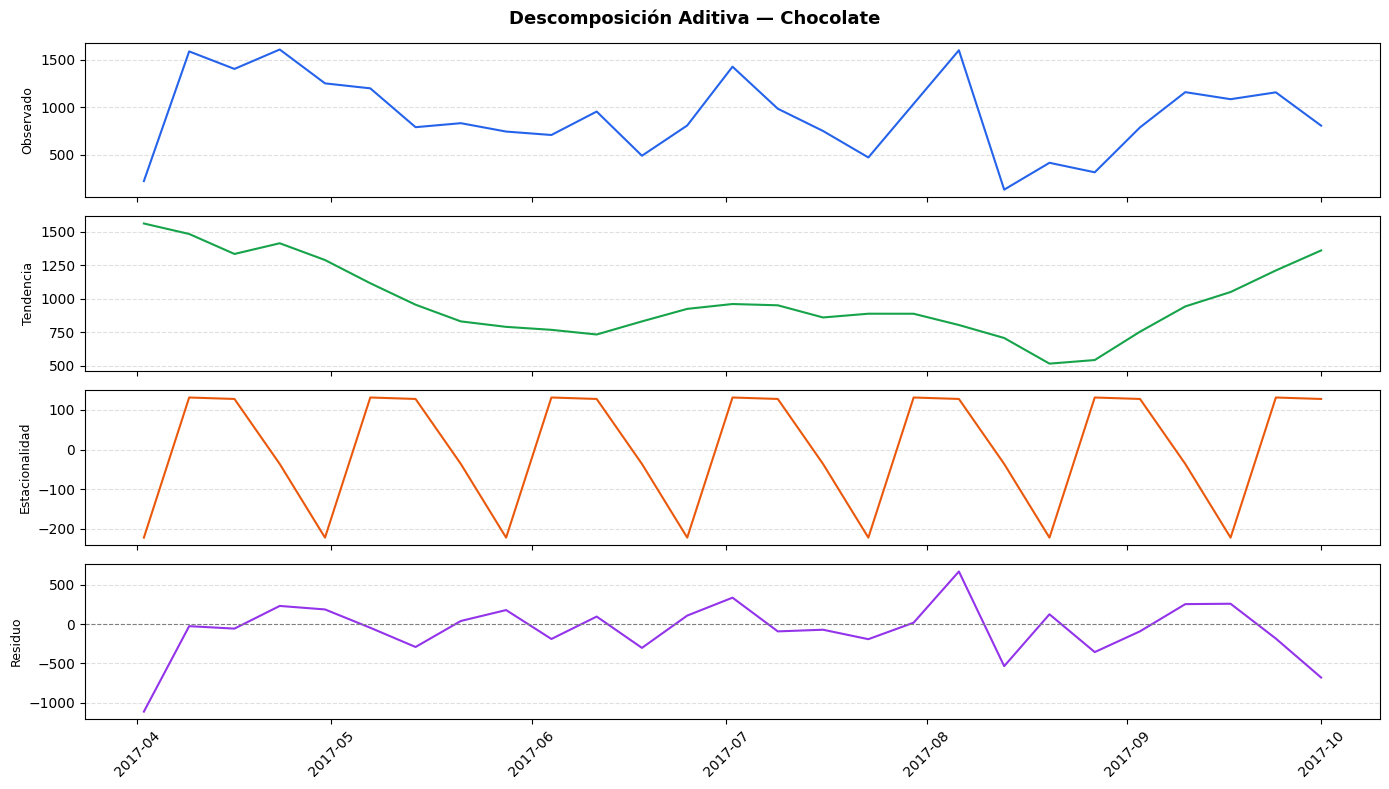

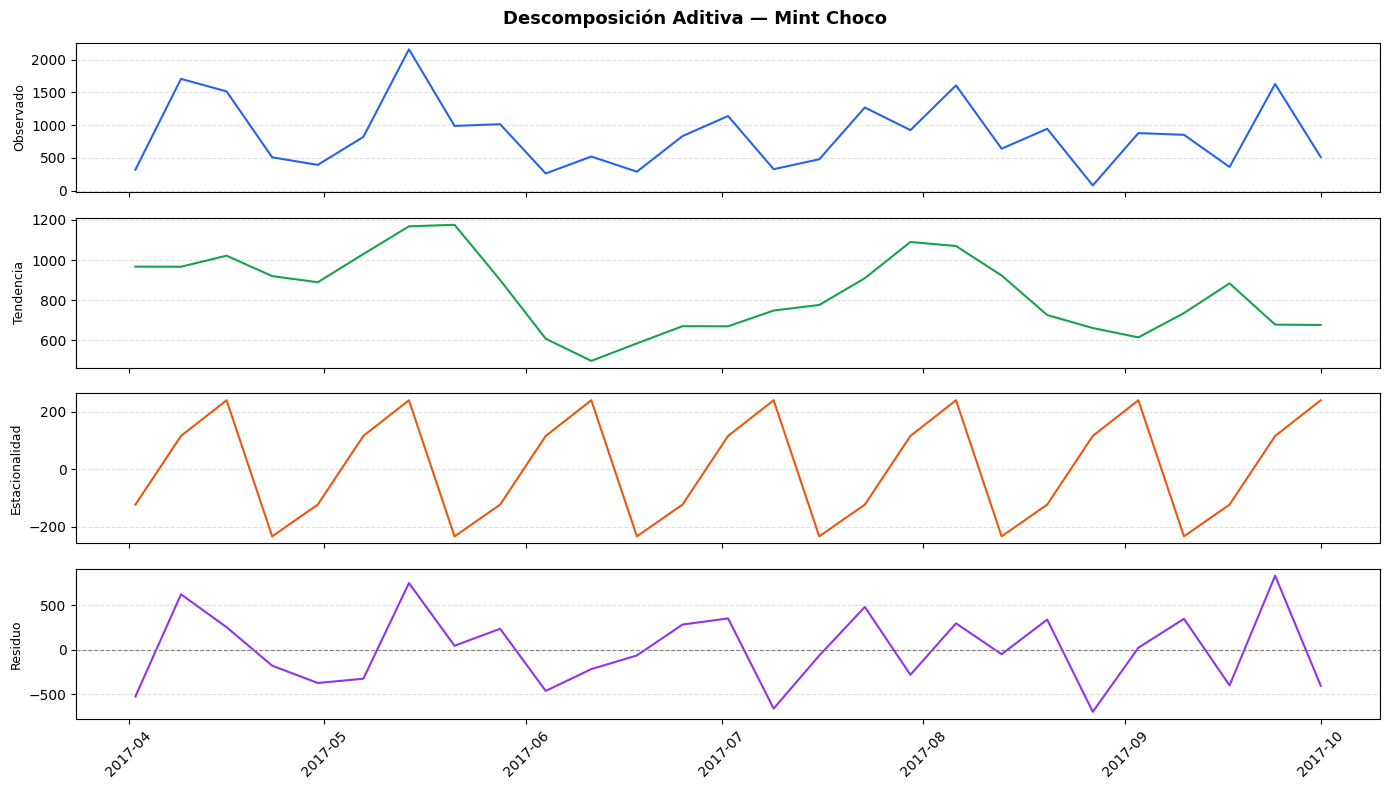

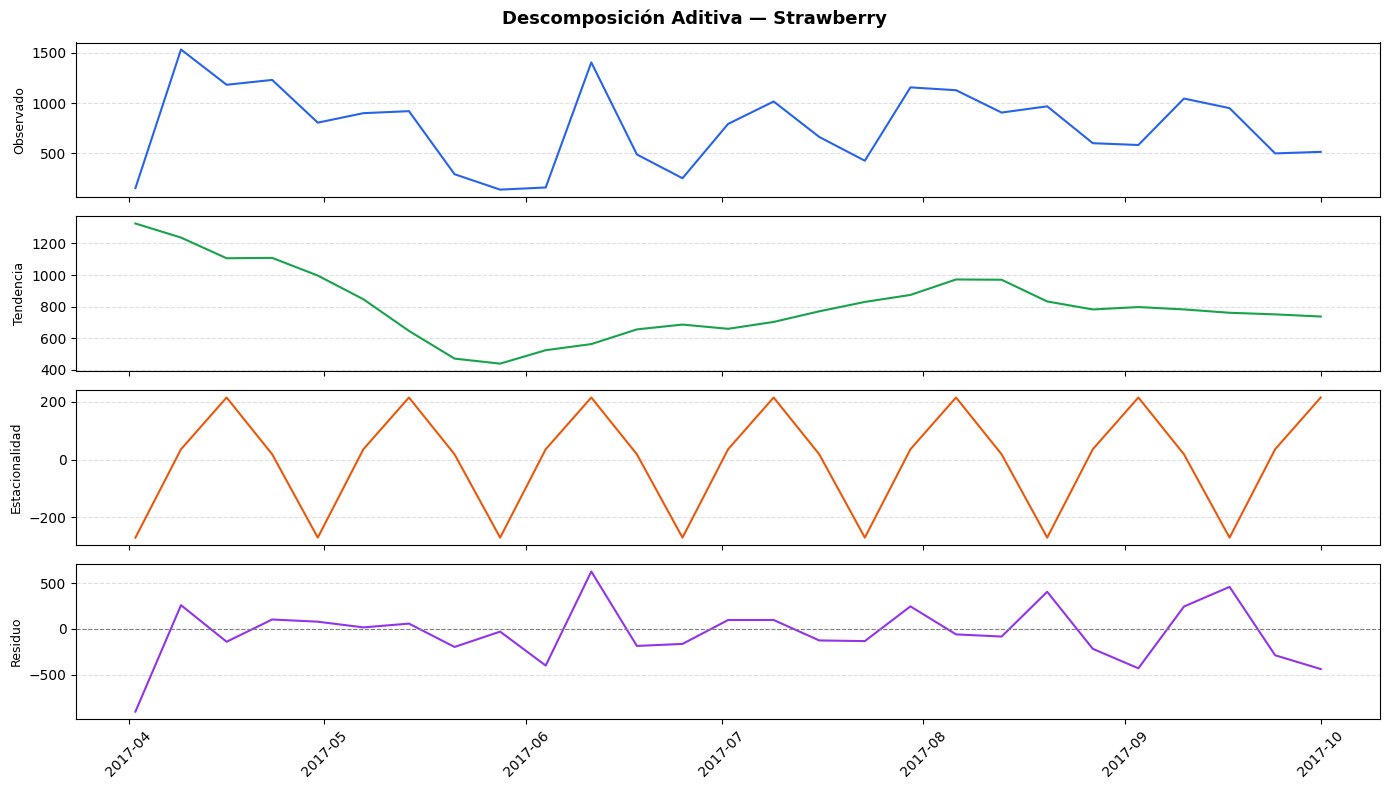

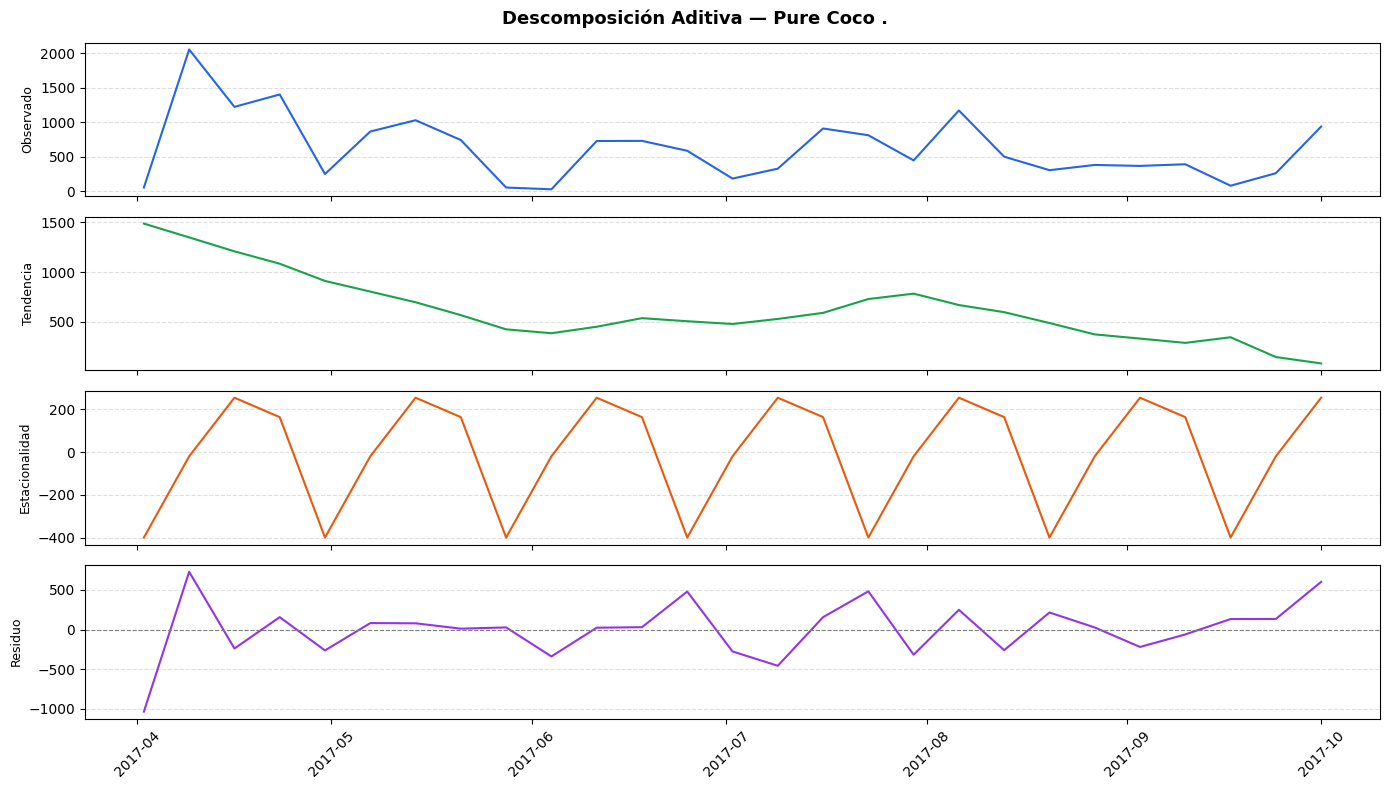

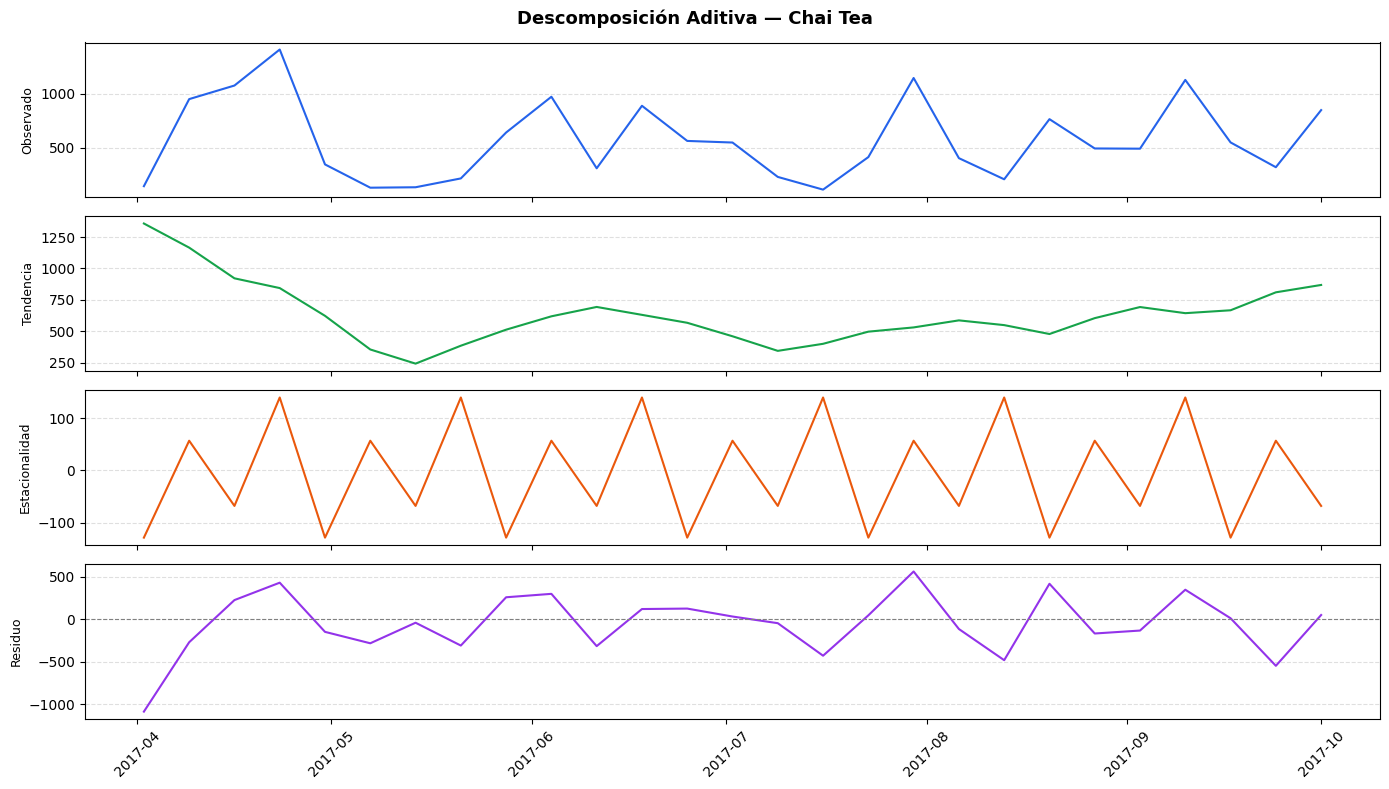

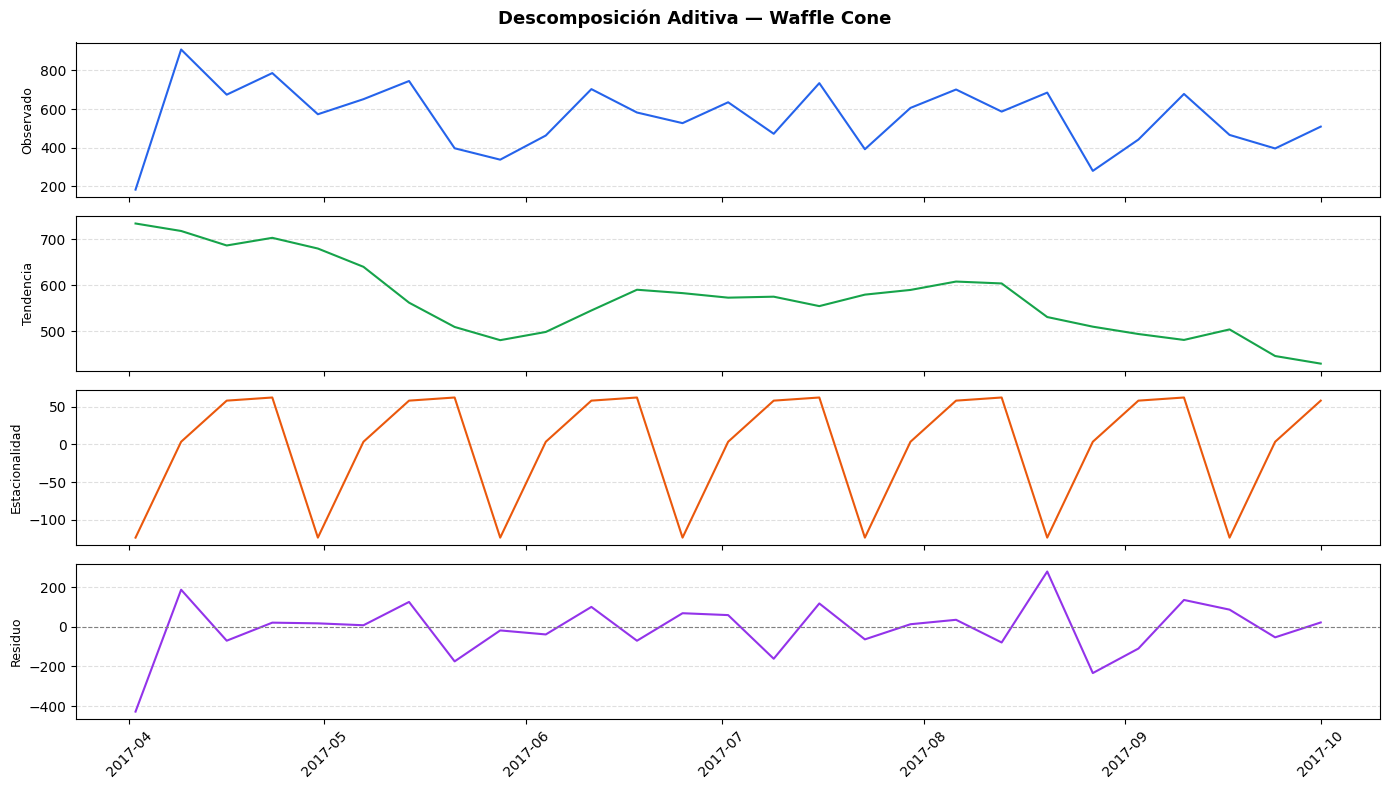

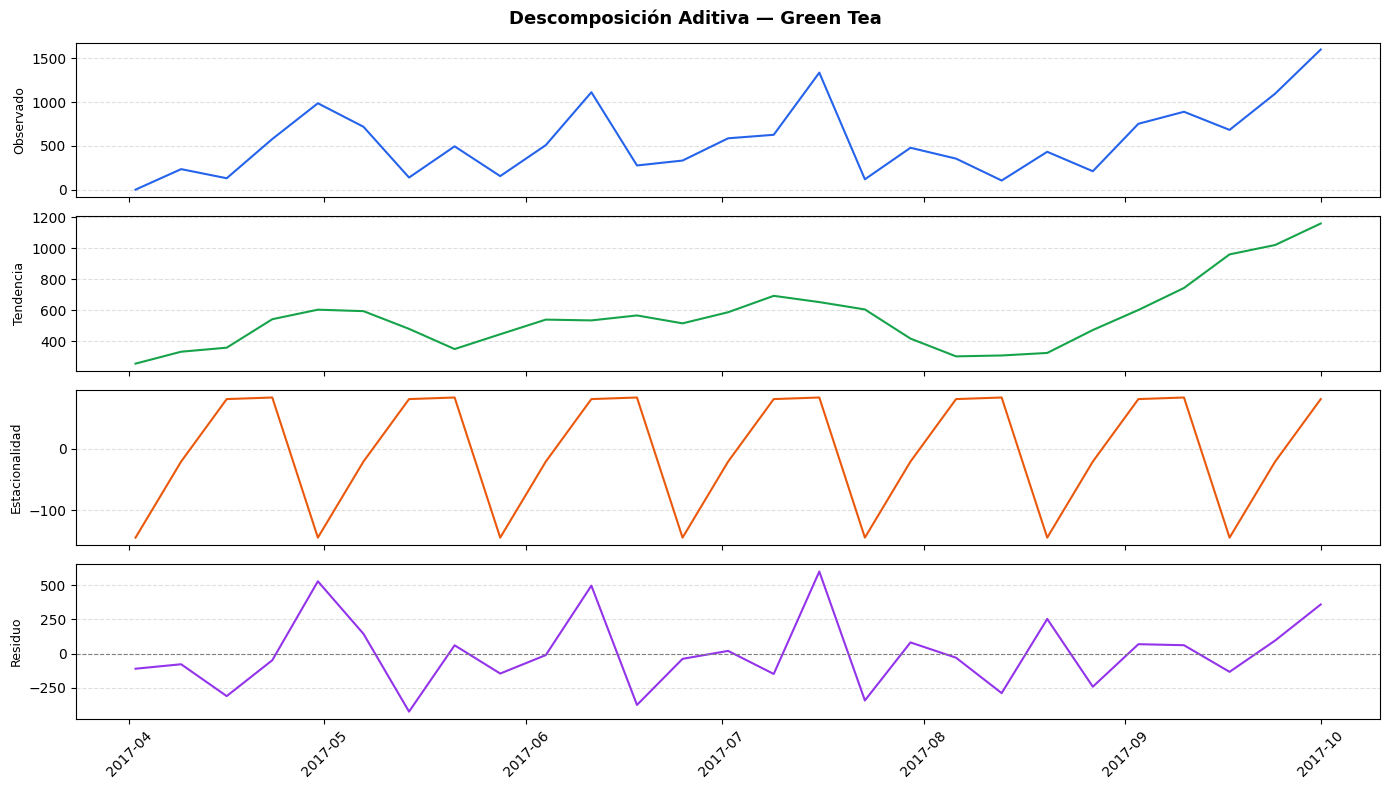

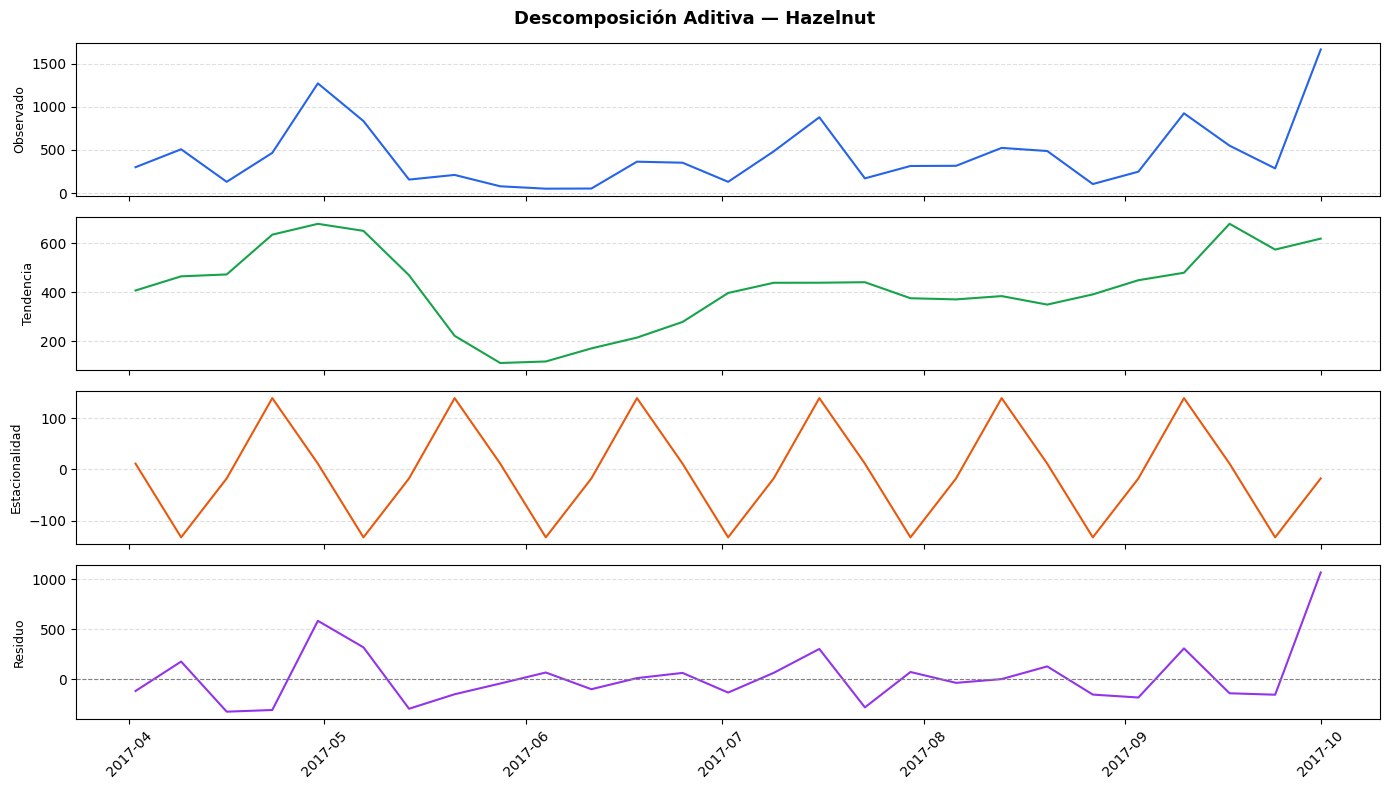

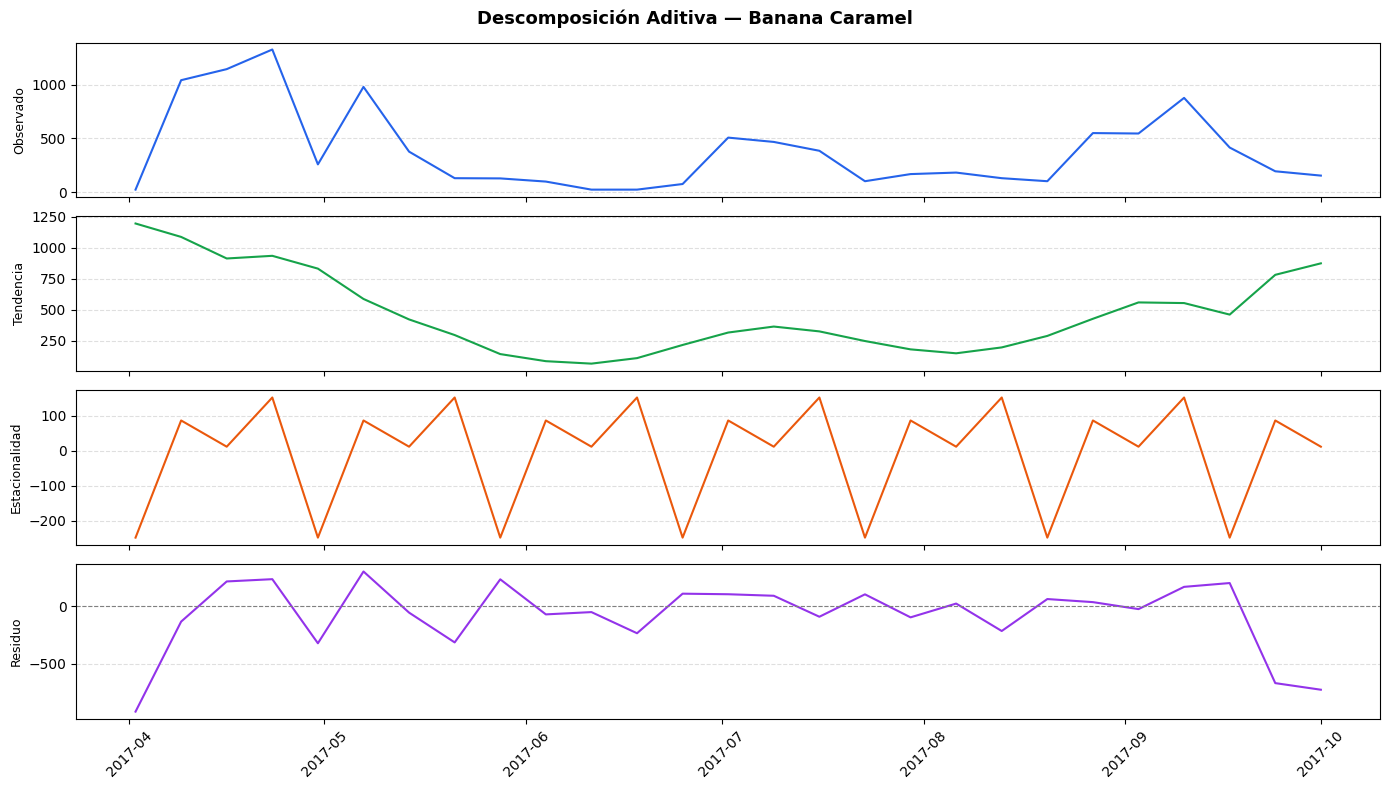

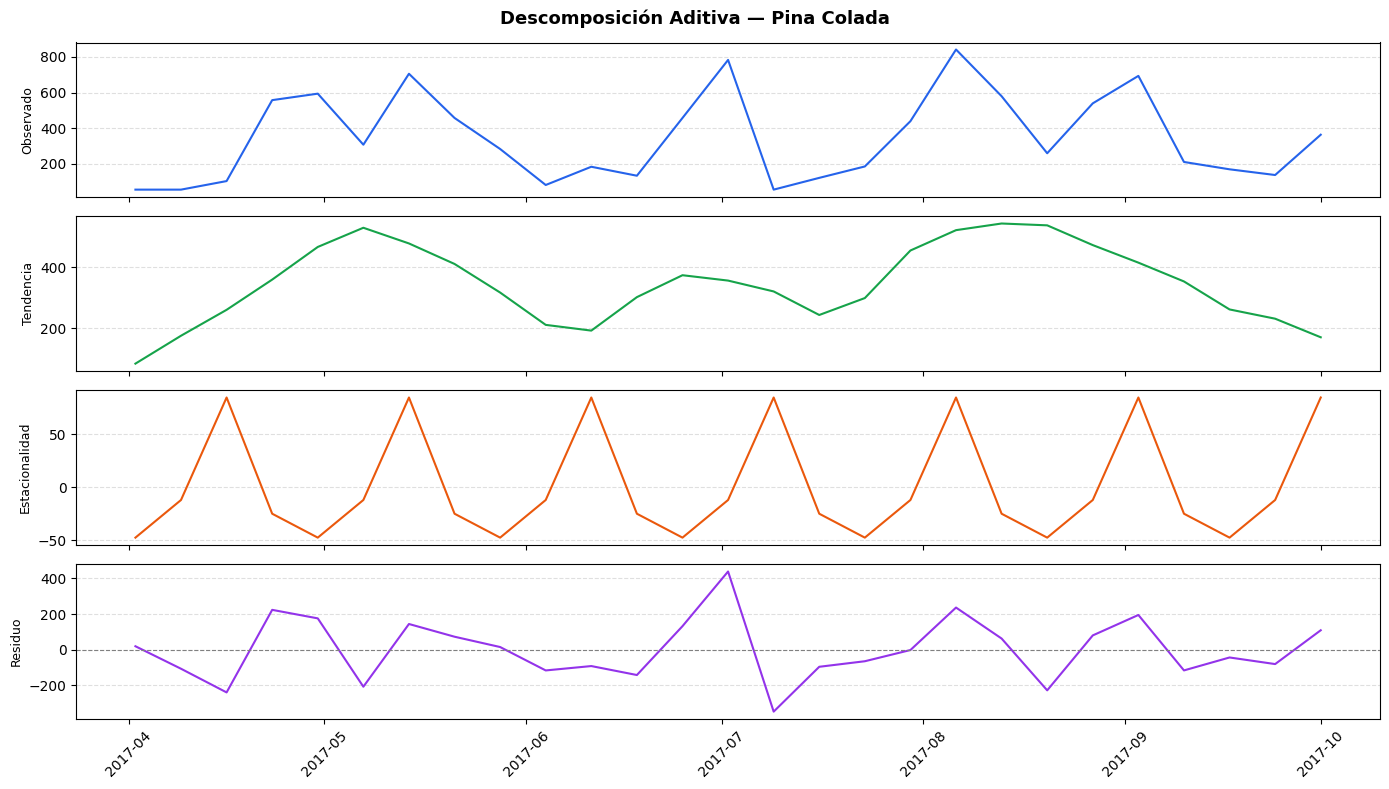

In [102]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── 1. Pivotear: filas=semanas, columnas=productos ──────────────────────────
data_pivot = (
    data
    .groupby(["Date_clean", product_col])["Revenue"]
    .sum()
    .unstack(product_col)
    .fillna(0)
)

# ── 2. Descomposición aditiva por producto ──────────────────────────────────
resultados = {}

for producto in productos_top_80:
    if producto not in data_pivot.columns:
        print(f"⚠️  '{producto}' no encontrado, se omite.")
        continue

    serie = data_pivot[producto]

    # seasonal_decompose necesita al menos 2 ciclos completos del periodo
    # Con datos semanales (~26 semanas) usamos period=4 (mensual aprox.)
    try:
        descomp = seasonal_decompose(serie, model="additive", period=4, extrapolate_trend="freq")
        resultados[producto] = descomp
    except Exception as e:
        print(f"❌ Error en '{producto}': {e}")

print(f"\n✅ Descomposición completada para {len(resultados)} productos.")

# ── 3. Graficar todas las descomposiciones ──────────────────────────────────
for producto, descomp in resultados.items():
    fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f"Descomposición Aditiva — {producto}", fontsize=13, fontweight="bold")

    componentes = [
        (descomp.observed,  "Observado",   "#2563eb"),
        (descomp.trend,     "Tendencia",   "#16a34a"),
        (descomp.seasonal,  "Estacionalidad", "#ea580c"),
        (descomp.resid,     "Residuo",     "#9333ea"),
    ]

    for ax, (serie, label, color) in zip(axes, componentes):
        ax.plot(serie, color=color, linewidth=1.5)
        ax.set_ylabel(label, fontsize=9)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        if label == "Residuo":
            ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")

    axes[-1].tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig(f"descomposicion_{producto.replace(' ', '_')}.png", dpi=120, bbox_inches="tight")
    plt.show()

Despues de hacer la descomposicion por producto analizaremos solo 1 de estos que es el S. Caramel siendo el mas importante. 

Se puso por estaciones periodo de 4 semanas, Iniciando con la grafica de observado podemos ver una alta variabilidad se notan picos de caidas fuertes lo que puede llegar a decir que la demanda no es estable y pueda estar influenciado por otros factores.

Continuando con la tendensia, se ve que a inicios tiene una bajada pero luego en el siguente mes como unio se puede ver que tiene n pico y vuelve a caer en agosto, esto nos dice que no hay un crecimiento sostenido si no que fluctua la denamda segun el tiempo lo que llegamos a creer que por las estaciones.

En la estacionalidad previamente definimos ciclos de 4 semanas en donde buscamos ciclos de 4 semanas segun la reglas del negocio.

Por ultimo el residuo muestra una alta dispercion lo que nos indica que hay factores externos que puedan afectar y estar presente.

# Punto 2

  Serie temporal — Revenue Total (top productos, semanal)
  Productos incluidos : 12 (top ~80% Pareto)
  Período             : 2017-04-02 → 2017-10-01
  Semanas             : 27
  Revenue promedio    : HKD      8,441 / semana
  Revenue mínimo      : HKD      2,259
  Revenue máximo      : HKD     14,960
  Desviación estándar : HKD      2,614
  CV (std/media)      : 31.0%  ← variabilidad relativa


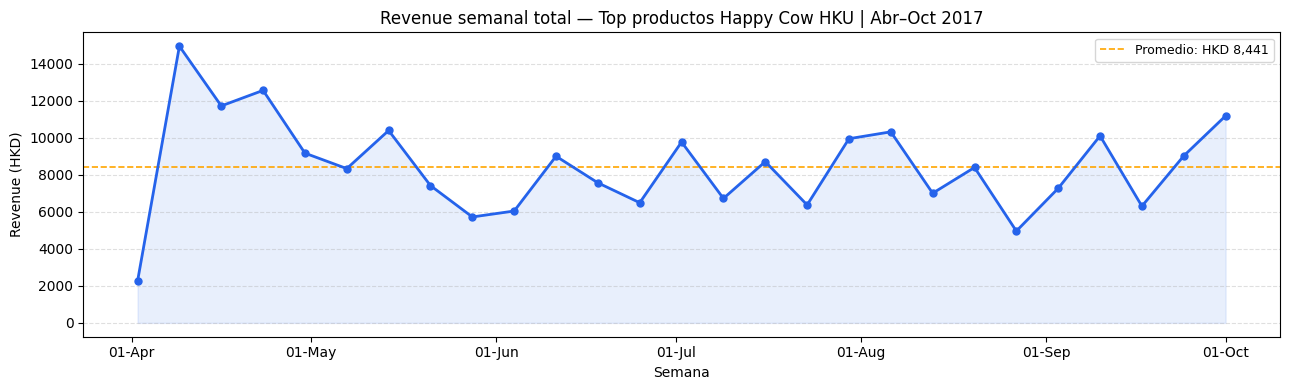

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
 
# ─────────────────────────────────────────────────────────────────────────────
# 2.1  Construir la serie de revenue TOTAL semanal (suma de todos los top productos)
#
# ¿Por qué agregar todos los productos del Pareto y no modelar uno a uno?
# Modelar cada producto por separado requeriría 12 modelos distintos, y cada
# uno tendría solo ~27 observaciones, lo que es insuficiente para capturar
# patrones confiables. Al sumar el revenue de todos los productos del Pareto
# obtenemos una única serie que:
#   (1) representa el 80% del negocio
#   (2) es más estable (los picos de un producto compensan los valles de otro)
#   (3) es directamente útil para decisiones de planificación de la tienda
# ─────────────────────────────────────────────────────────────────────────────
 
revenue_semanal = (
    data
    .groupby('Date_clean')['Revenue']
    .sum()
    .reset_index()
    .rename(columns={'Date_clean': 'ds', 'Revenue': 'y'})
    .sort_values('ds')
    .reset_index(drop=True)
)
 
print("=" * 58)
print("  Serie temporal — Revenue Total (top productos, semanal)")
print("=" * 58)
print(f"  Productos incluidos : {data['Product_clean'].nunique()} (top ~80% Pareto)")
print(f"  Período             : {revenue_semanal['ds'].min().date()} → {revenue_semanal['ds'].max().date()}")
print(f"  Semanas             : {len(revenue_semanal)}")
print(f"  Revenue promedio    : HKD {revenue_semanal['y'].mean():>10,.0f} / semana")
print(f"  Revenue mínimo      : HKD {revenue_semanal['y'].min():>10,.0f}")
print(f"  Revenue máximo      : HKD {revenue_semanal['y'].max():>10,.0f}")
print(f"  Desviación estándar : HKD {revenue_semanal['y'].std():>10,.0f}")
print(f"  CV (std/media)      : {revenue_semanal['y'].std()/revenue_semanal['y'].mean()*100:.1f}%  ← variabilidad relativa")
 
# Gráfico de la serie completa
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(revenue_semanal['ds'], revenue_semanal['y'],
        marker='o', color='#2563eb', linewidth=2, markersize=5, zorder=3)
ax.fill_between(revenue_semanal['ds'], revenue_semanal['y'],
                alpha=0.1, color='#2563eb')
ax.axhline(revenue_semanal['y'].mean(), color='orange', linestyle='--',
           linewidth=1.2, label=f"Promedio: HKD {revenue_semanal['y'].mean():,.0f}")
ax.set_title('Revenue semanal total — Top productos Happy Cow HKU | Abr–Oct 2017',
             fontsize=12)
ax.set_ylabel('Revenue (HKD)')
ax.set_xlabel('Semana')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


  Observaciones de la serie:
  - Semana 1 (01-Abr): revenue muy bajo (HKD 2,259) — primeros días de apertura.
  - La serie muestra alta variabilidad semana a semana sin tendencia clara.
  - No hay suficientes datos para identificar estacionalidad anual,
    pero sí ciclos de corto plazo (cada ~4 semanas, como se vio en Punto 1).

### Separación temporal: Train / Test

In [108]:
HORIZONTE = 4
 
train = revenue_semanal.iloc[:-HORIZONTE].copy().reset_index(drop=True)
test  = revenue_semanal.iloc[-HORIZONTE:].copy().reset_index(drop=True)
 

print(f"  TRAIN : {len(train)} semanas  "
      f"({train['ds'].min().date()} → {train['ds'].max().date()})")
print(f"  TEST  : {len(test)} semanas   "
      f"({test['ds'].min().date()} → {test['ds'].max().date()})")


  TRAIN : 23 semanas  (2017-04-02 → 2017-09-03)
  TEST  : 4 semanas   (2017-09-10 → 2017-10-01)


El modelo SOLO puede usar información del train.

El test simula las 4 semanas 'futuras' que queremos predecir.

### Establesemos un punto de comparacion

In [109]:
VENTANA_MA = 4
 
# Predicción: promedio de las últimas 4 semanas del train (valor constante)
pred_base_valor = train['y'].rolling(VENTANA_MA).mean().iloc[-1]
pred_base       = np.array([pred_base_valor] * HORIZONTE)
 
print("\n" + "=" * 58)
print(f"  Modelo Base — Media Móvil ({VENTANA_MA} semanas)")
print("=" * 58)
print(f"  Últimas {VENTANA_MA} semanas del train usadas para el promedio:")
for _, row in train.tail(VENTANA_MA).iterrows():
    print(f"    {row['ds'].date()}  →  HKD {row['y']:>10,.0f}")
print(f"\n  Predicción constante: HKD {pred_base_valor:,.0f} / semana")
print(f"  → Se repite este valor para las {HORIZONTE} semanas del horizonte")


  Modelo Base — Media Móvil (4 semanas)
  Últimas 4 semanas del train usadas para el promedio:
    2017-08-13  →  HKD      7,010
    2017-08-20  →  HKD      8,403
    2017-08-27  →  HKD      4,964
    2017-09-03  →  HKD      7,276

  Predicción constante: HKD 6,913 / semana
  → Se repite este valor para las 4 semanas del horizonte


### Métricas de evaluación

In [110]:
y_real = test['y'].values
y_pred = pred_base
 
mae  = np.mean(np.abs(y_real - y_pred))
rmse = np.sqrt(np.mean((y_real - y_pred) ** 2))
mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
 
metricas_base = {
    'modelo': f'Media Móvil {VENTANA_MA} sem.',
    'MAE': mae, 'RMSE': rmse, 'MAPE': mape
}
 
print("\n" + "=" * 58)
print("  Métricas del Modelo Base (evaluadas sobre el test)")
print("=" * 58)
print(f"  MAE  = HKD {mae:>8,.0f}   ← error promedio por semana")
print(f"  RMSE = HKD {rmse:>8,.0f}   ← penaliza errores grandes")
print(f"  MAPE = {mape:>8.1f}%   ← error relativo promedio")
 
# Tabla detallada semana a semana
print(f"\n  Detalle por semana:")
print(f"  {'Semana':<12} {'Real (HKD)':>12} {'Pred (HKD)':>12} "
      f"{'Error':>10} {'|Error|%':>9}")
print(f"  {'─'*57}")
for i in range(HORIZONTE):
    err  = y_real[i] - y_pred[i]
    errp = abs(err) / y_real[i] * 100
    fecha = test['ds'].iloc[i].strftime('%Y-%m-%d')
    print(f"  {fecha:<12} {y_real[i]:>12,.0f} {y_pred[i]:>12,.0f} "
          f"{err:>+10,.0f} {errp:>8.1f}%")
print(f"  {'─'*57}")
print(f"  {'PROMEDIO':<12} {y_real.mean():>12,.0f} {y_pred.mean():>12,.0f} "
      f"  {'MAE →':>10} {mape:>8.1f}%")


  Métricas del Modelo Base (evaluadas sobre el test)
  MAE  = HKD    2,549   ← error promedio por semana
  RMSE = HKD    2,889   ← penaliza errores grandes
  MAPE =     25.7%   ← error relativo promedio

  Detalle por semana:
  Semana         Real (HKD)   Pred (HKD)      Error  |Error|%
  ─────────────────────────────────────────────────────────
  2017-09-10         10,112        6,913     +3,199     31.6%
  2017-09-17          6,310        6,913       -603      9.6%
  2017-09-24          9,028        6,913     +2,115     23.4%
  2017-10-01         11,193        6,913     +4,280     38.2%
  ─────────────────────────────────────────────────────────
  PROMEDIO            9,161        6,913        MAE →     25.7%


ex

###  Gráfico Train / Test / Predicción Base

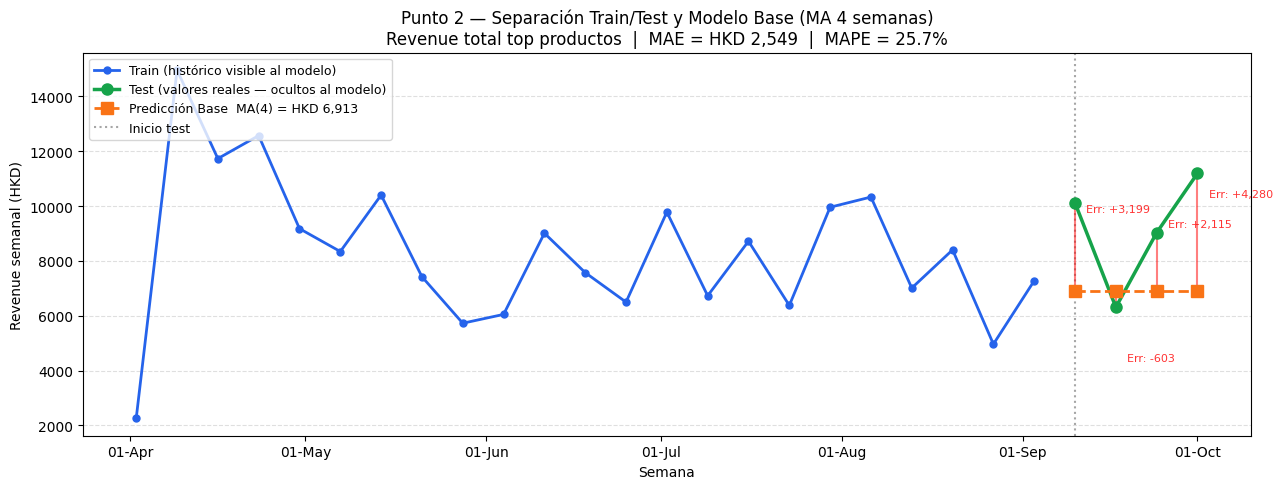

In [111]:
fig, ax = plt.subplots(figsize=(13, 5))
 
# Train
ax.plot(train['ds'], train['y'],
        marker='o', color='#2563eb', linewidth=2, markersize=5,
        label='Train (histórico visible al modelo)')
 
# Test real
ax.plot(test['ds'], test['y'],
        marker='o', color='#16a34a', linewidth=2.5, markersize=8,
        label='Test (valores reales — ocultos al modelo)', zorder=4)
 
# Predicción base
ax.plot(test['ds'], pred_base,
        marker='s', linestyle='--', color='#f97316', linewidth=2, markersize=8,
        label=f'Predicción Base  MA({VENTANA_MA}) = HKD {pred_base_valor:,.0f}', zorder=4)
 
# Barras de error verticales
for i in range(HORIZONTE):
    ax.plot([test['ds'].iloc[i], test['ds'].iloc[i]],
            [y_pred[i], y_real[i]],
            color='red', linewidth=1.5, linestyle='-', alpha=0.5, zorder=3)
 
# Línea de corte
ax.axvline(test['ds'].iloc[0], color='gray',
           linestyle=':', linewidth=1.5, alpha=0.7, label='Inicio test')
 
# Anotaciones de error
for i in range(HORIZONTE):
    err = y_real[i] - y_pred[i]
    offset = 25 if err > 0 else -45
    ax.annotate(f'Err: {err:+,.0f}',
                xy=(test['ds'].iloc[i], (y_real[i] + y_pred[i]) / 2),
                xytext=(8, offset), textcoords='offset points',
                fontsize=8, color='red', alpha=0.8)
 
ax.set_title(
    f'Punto 2 — Separación Train/Test y Modelo Base (MA {VENTANA_MA} semanas)\n'
    f'Revenue total top productos  |  MAE = HKD {mae:,.0f}  |  MAPE = {mape:.1f}%',
    fontsize=12)
ax.set_ylabel('Revenue semanal (HKD)')
ax.set_xlabel('Semana')
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
plt.tight_layout()
plt.show()

In [ ]:
Conclusiones: 

# Punto 3

# Punto 4